In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
import numpy as np
from sklearn.metrics import mean_squared_error

In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv


--2026-10-07 15:13:27--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.08s   

2026-10-07 15:13:27 (7.23 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [8]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
print(df.head())

   model_year  origin fuel_type         drivetrain  num_doors  \
0        2006  Europe  Gasoline  Front-wheel drive          4   
1        2008  Europe    Diesel  Front-wheel drive          4   
2        1996    Asia  Gasoline  Front-wheel drive          5   
3        1989  Europe  Gasoline  Front-wheel drive          4   
4        1994     USA    Diesel  Front-wheel drive          3   

   engine_displacement  num_cylinders  horsepower  vehicle_weight  \
0                 2180              6       243.0            3870   
1                 2390              6       272.0            4210   
2                 2320              6       267.0            4240   
3                 2130              6       258.0            4490   
4                 2580              7       304.0            4510   

   acceleration  fuel_efficiency_mpg  
0           NaN                 31.9  
1           NaN                 31.3  
2          17.3                 27.5  
3          18.7                 28.5  

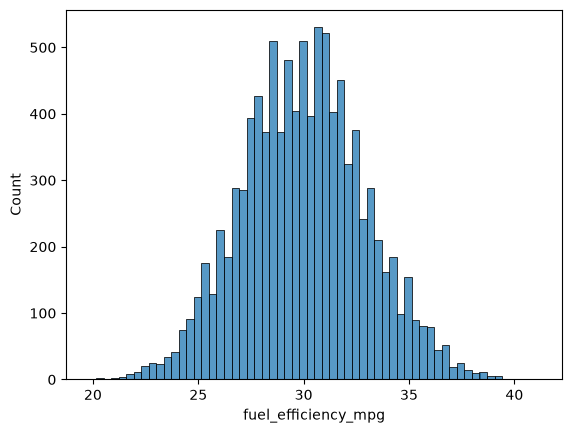

In [18]:
sns.histplot(df['fuel_efficiency_mpg'], kde=False)
plt.show()

In [26]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [40]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [27]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [15]:
horsepower_mean = df['horsepower'].mean()
print(f"Mean horsepower: {horsepower_mean}")

Mean horsepower: 254.44601556505535


In [16]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [35]:
mean_horsepower = fill_with_0['horsepower'].mean()
mean_horsepower = df_train['horsepower'].mean()

In [36]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

# Fill with 0
fill_with_0 = df_train.fillna(0)

X_train_0_fill = fill_with_0[features]
y_train_0_fill = fill_with_0['fuel_efficiency_mpg']

# Fill with training mean
mean_horsepower = df_train['horsepower'].mean()

fill_with_mean = df_train.fillna({
    'horsepower': mean_horsepower
})

X_train_mean_fill = fill_with_mean[features]

In [37]:
# Validation - fill with 0
val_0_fill = df_val.fillna(0)

X_val_0_fill = val_0_fill[features]
y_val = df_val['fuel_efficiency_mpg']

# Validation - fill with SAME training mean
val_mean_fill = df_val.fillna({
    'horsepower': mean_horsepower
})

X_val_mean_fill = val_mean_fill[features]

In [38]:
pred_0 = model_0_fill.predict(X_val_0_fill)
pred_mean = model_mean_fill.predict(X_val_mean_fill)

rmse_0 = np.sqrt(mean_squared_error(y_val, pred_0))
rmse_mean = np.sqrt(mean_squared_error(y_val, pred_mean))

print("0 fill:", round(rmse_0, 3))
print("Mean fill:", round(rmse_mean, 3))

0 fill: 2.205
Mean fill: 2.203


In [41]:
regularization_strengths = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in regularization_strengths:
    w0, w = train_linear_regression_reg(
        X_train_0_fill.values,
        y_train_0_fill.values,
        r=r
    )

    y_pred = w0 + X_val_0_fill.values.dot(w)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    print(f"r={r}: RMSE={round(rmse, 4)}")

r=0: RMSE=2.2053
r=0.01: RMSE=2.2058
r=0.1: RMSE=2.2241
r=1: RMSE=2.3492
r=5: RMSE=2.4094
r=10: RMSE=2.4195
r=100: RMSE=2.4292


In [42]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

scores = []

for seed in seeds:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    # Fill missing values with 0
    X_train = df_train[features].fillna(0).values
    X_val = df_val[features].fillna(0).values

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    # No regularization
    w0, w = train_linear_regression_reg(X_train, y_train, r=0)

    y_pred = w0 + X_val.dot(w)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    scores.append(rmse)

    print(seed, rmse)

std = np.std(scores)

print("std:", std)
print("rounded:", round(std, 3))

0 2.239204143051171
1 2.2021128210833383
2 2.163419778753089
3 2.2043588768501907
4 2.201880094330856
5 2.2457851509085045
6 2.2697212079514624
7 2.19079459993641
8 2.216611201697255
9 2.2070365928266966
std: 0.028781274078249642
rounded: 0.029


In [44]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

df_train_val = pd.concat([df_train, df_val])

X_train_val = df_train_val[features].fillna(0).values
y_train_val = df_train_val['fuel_efficiency_mpg'].values

X_test = df_test[features].fillna(0).values
y_test = df_test['fuel_efficiency_mpg'].values

w0, w = train_linear_regression_reg(
    X_train_val,
    y_train_val,
    r=0.001
)

y_pred = w0 + X_test.dot(w)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)
print("Rounded:", round(rmse, 3))

Test RMSE: 2.2358277471945915
Rounded: 2.236
